# 🧠 Ternary Neural Networks — Phase 1 (QAT Edition)
**Quantization-Aware Training on CIFAR-10 / ResNet-18**

### Why QAT instead of post-training quantization?

Post-training quantization (what we tried before):
- Train normally with float weights
- Snap weights to {−1, 0, +1} afterward
- Network was never prepared for this → big accuracy drop (43–60%)

Quantization-Aware Training (QAT):
- **Simulate** ternary weights during training using the Straight-Through Estimator (STE)
- Forward pass uses fake ternary weights → network sees what inference will look like
- Backward pass uses real float weights → gradients still flow, training still works
- Network learns to be robust to ternary constraints from the start
- Result: much smaller accuracy drop

### The Straight-Through Estimator (STE) — key idea
Snapping weights to {−1, 0, +1} is not differentiable (gradient = 0 everywhere).
STE trick: in the backward pass, pretend the quantization never happened.
Pass gradients straight through as if the operation was identity.
This lets the optimizer keep nudging the real float weights in the right direction.

---
**Strategy:**
1. Train baseline ResNet-18 for 15 epochs (same as before)
2. Fine-tune with QAT for 10 more epochs (simulated ternary weights)
3. Snap to real ternary weights + BN recalibration
4. Evaluate and compare

## 1. Setup & Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import copy
import pandas as pd
from IPython.display import display

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## 2. Load CIFAR-10

In [ ]:
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

calib_indices = torch.randperm(len(train_dataset))[:2000].tolist()
calib_loader  = DataLoader(Subset(train_dataset, calib_indices),
                           batch_size=128, shuffle=False, num_workers=2)

print(f'Train samples       : {len(train_dataset):,}')
print(f'Test  samples       : {len(test_dataset):,}')
print(f'Calibration samples : {len(calib_indices):,}')

100%|██████████| 170M/170M [01:43<00:00, 1.65MB/s]


Train samples       : 50,000
Test  samples       : 10,000
Calibration samples : 2,000


## 3. Straight-Through Estimator (STE)

This is the core of QAT. It's a custom PyTorch autograd function.

- **Forward:** snap weights to {−1, 0, +1} using threshold
- **Backward:** pass gradients through unchanged (pretend quantization didn't happen)

This means the optimizer keeps updating real float weights,
but the network always *sees* ternary weights during the forward pass.

In [ ]:
class TernaryQuantizeSTE(torch.autograd.Function):
    """
    Straight-Through Estimator for ternary quantization.

    Forward : w → ternarize(w, alpha)
    Backward: grad_output passed straight through (identity)
    """
    @staticmethod
    def forward(ctx, weight, alpha):
        t       = alpha * weight.abs().max()
        ternary = torch.zeros_like(weight)
        ternary[weight >  t] =  1.0
        ternary[weight < -t] = -1.0
        return ternary

    @staticmethod
    def backward(ctx, grad_output):
        # Straight-through: pass gradient unchanged, None for alpha (not learnable)
        return grad_output, None


def ternary_ste(weight, alpha):
    return TernaryQuantizeSTE.apply(weight, alpha)


print('✅ STE defined.')
print()
print('What happens during training:')
print('  Forward  → network uses fake ternary weights {-1, 0, +1}')
print('  Backward → gradients flow through as if weights were float')
print('  Update   → real float weights get nudged by optimizer')
print('  Result   → weights gradually learn to cluster near -1, 0, +1')

✅ STE defined.

What happens during training:
  Forward  → network uses fake ternary weights {-1, 0, +1}
  Backward → gradients flow through as if weights were float
  Update   → real float weights get nudged by optimizer
  Result   → weights gradually learn to cluster near -1, 0, +1


## 4. QAT-Aware ResNet-18

We wrap each Conv2d and Linear layer so that during the forward pass,
weights are automatically ternarized via STE before being used.
The stored weights remain float — only the computation uses ternary values.

In [ ]:
class TernaryConv2d(nn.Conv2d):
    """Conv2d that uses ternarized weights in forward pass (STE in backward)."""
    def __init__(self, *args, alpha=0.1, **kwargs):
        super().__init__(*args, **kwargs)
        self.alpha = alpha

    def forward(self, x):
        # Use ternary weights for computation, keep float weights for gradient
        ternary_w = ternary_ste(self.weight, self.alpha)
        return nn.functional.conv2d(
            x, ternary_w, self.bias,
            self.stride, self.padding, self.dilation, self.groups
        )


class TernaryLinear(nn.Linear):
    """Linear layer that uses ternarized weights in forward pass (STE in backward)."""
    def __init__(self, *args, alpha=0.1, **kwargs):
        super().__init__(*args, **kwargs)
        self.alpha = alpha

    def forward(self, x):
        ternary_w = ternary_ste(self.weight, self.alpha)
        return nn.functional.linear(x, ternary_w, self.bias)


def replace_with_ternary_layers(model, alpha):
    """
    Walk through the model and swap every Conv2d and Linear
    with their QAT-aware ternary equivalents.
    Copies the original float weights over so training continues
    from where the baseline left off.
    """
    for name, module in model.named_children():
        if isinstance(module, nn.Conv2d):
            new_layer = TernaryConv2d(
                module.in_channels, module.out_channels,
                kernel_size=module.kernel_size, stride=module.stride,
                padding=module.padding, dilation=module.dilation,
                groups=module.groups,
                bias=(module.bias is not None),
                alpha=alpha
            )
            new_layer.weight.data = module.weight.data.clone()
            if module.bias is not None:
                new_layer.bias.data = module.bias.data.clone()
            setattr(model, name, new_layer)

        elif isinstance(module, nn.Linear):
            new_layer = TernaryLinear(
                module.in_features, module.out_features,
                bias=(module.bias is not None),
                alpha=alpha
            )
            new_layer.weight.data = module.weight.data.clone()
            if module.bias is not None:
                new_layer.bias.data = module.bias.data.clone()
            setattr(model, name, new_layer)

        else:
            # Recurse into submodules (residual blocks, etc.)
            replace_with_ternary_layers(module, alpha)

    return model


print('✅ TernaryConv2d and TernaryLinear defined.')

✅ TernaryConv2d and TernaryLinear defined.


## 5. Training Utilities

In [ ]:
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
            out  = model(x)
            loss = criterion(out, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * y.size(0)
        correct    += out.argmax(1).eq(y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        correct += model(x).argmax(1).eq(y).sum().item()
        total   += y.size(0)
    return correct / total


def recalibrate_batchnorm(model, calib_loader, n_batches=16):
    """Reset and recompute BN running stats for current weight regime."""
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.reset_running_stats()
            module.momentum = None
    model.train()
    with torch.no_grad():
        for i, (x, _) in enumerate(calib_loader):
            if i >= n_batches: break
            model(x.to(DEVICE))
    model.eval()


def build_resnet18_cifar():
    model = resnet18(weights=None)
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc      = nn.Linear(model.fc.in_features, 10)
    return model


def compute_weight_stats(model):
    """Compute ternary weight distribution across all Conv2d + Linear layers."""
    all_w = []
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear,
                               TernaryConv2d, TernaryLinear)):
            w = module.weight.data.cpu().float().numpy().flatten()
            all_w.extend(w.tolist())
    all_w = np.array(all_w)
    total = len(all_w)
    return {
        'pct_neg':  100 * (all_w == -1).sum() / total,
        'pct_zero': 100 * (all_w ==  0).sum() / total,
        'pct_pos':  100 * (all_w ==  1).sum() / total,
    }

print('✅ Utilities ready.')

✅ Utilities ready.


## 6. Step 1 — Train Baseline (Float)
Same as before. 15 epochs, OneCycleLR.

In [ ]:
model     = build_resnet18_cifar().to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scaler    = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))

BASELINE_EPOCHS = 15
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=0.1,
    epochs=BASELINE_EPOCHS, steps_per_epoch=len(train_loader)
)

baseline_losses, baseline_accs = [], []

print('── Baseline Training (Float Weights) ──')
print(f'{'Epoch':>6}  {'Train Loss':>11}  {'Train Acc':>10}  {'Val Acc':>9}')
print('-' * 48)

for epoch in range(1, BASELINE_EPOCHS + 1):
    loss, tacc = train_epoch(model, train_loader, optimizer, criterion, scaler)
    vacc       = evaluate(model, test_loader)
    scheduler.step()
    baseline_losses.append(loss)
    baseline_accs.append(vacc)
    print(f'{epoch:>6}  {loss:>11.4f}  {tacc*100:>9.2f}%  {vacc*100:>8.2f}%')

baseline_accuracy = baseline_accs[-1]
print(f'\n✅ Baseline accuracy: {baseline_accuracy*100:.2f}%')

# Save baseline weights so we can restore for fair PTQ comparison
baseline_state = copy.deepcopy(model.state_dict())

── Baseline Training (Float Weights) ──
 Epoch   Train Loss   Train Acc    Val Acc
------------------------------------------------
     1       1.7763      39.44%     54.05%
     2       1.4284      58.24%     62.47%
     3       1.2742      65.85%     68.05%
     4       1.1739      70.57%     69.79%
     5       1.0867      74.65%     75.39%
     6       1.0284      77.61%     77.12%
     7       0.9850      79.66%     80.03%
     8       0.9379      81.65%     77.84%
     9       0.9068      83.07%     81.25%
    10       0.8809      84.27%     82.40%
    11       0.8560      85.43%     83.94%
    12       0.8366      86.35%     83.56%
    13       0.8162      87.21%     84.87%
    14       0.7996      88.12%     83.37%
    15       0.7794      88.81%     85.31%

✅ Baseline accuracy: 85.31%


## 7. Step 2 — QAT Fine-tuning

We take the trained baseline and continue training with simulated ternary weights.
The network learns to be robust to {−1, 0, +1} constraints.

Key differences from baseline training:
- Lower learning rate (we're fine-tuning, not training from scratch)
- Ternary layers replace all Conv2d + Linear
- Forward pass uses fake ternary weights via STE

In [ ]:
QAT_ALPHA  = 0.1   # threshold for ternary quantization during QAT
QAT_EPOCHS = 10

# Start from the trained baseline — replace layers with ternary-aware versions
qat_model = copy.deepcopy(model)
qat_model = replace_with_ternary_layers(qat_model, alpha=QAT_ALPHA)
qat_model = qat_model.to(DEVICE)

# Lower LR for fine-tuning
qat_optimizer = optim.SGD(qat_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
qat_scheduler = optim.lr_scheduler.CosineAnnealingLR(qat_optimizer, T_max=QAT_EPOCHS)
qat_scaler    = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))
qat_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

qat_losses, qat_accs = [], []

print(f'── QAT Fine-tuning (Simulated Ternary, α={QAT_ALPHA}) ──')
print('   Forward pass: fake ternary weights {-1, 0, +1}')
print('   Backward pass: gradients flow through float weights')
print()
print(f'{'Epoch':>6}  {'Train Loss':>11}  {'Train Acc':>10}  {'Val Acc (simulated ternary)':>28}')
print('-' * 65)

for epoch in range(1, QAT_EPOCHS + 1):
    loss, tacc = train_epoch(qat_model, train_loader, qat_optimizer, qat_criterion, qat_scaler)
    vacc       = evaluate(qat_model, test_loader)   # uses fake ternary in forward
    qat_scheduler.step()
    qat_losses.append(loss)
    qat_accs.append(vacc)
    print(f'{epoch:>6}  {loss:>11.4f}  {tacc*100:>9.2f}%  {vacc*100:>28.2f}%')

qat_simulated_accuracy = qat_accs[-1]
print(f'\n✅ QAT simulated accuracy (fake ternary): {qat_simulated_accuracy*100:.2f}%')

── QAT Fine-tuning (Simulated Ternary, α=0.1) ──
   Forward pass: fake ternary weights {-1, 0, +1}
   Backward pass: gradients flow through float weights

 Epoch   Train Loss   Train Acc   Val Acc (simulated ternary)
-----------------------------------------------------------------
     1       2.7098      70.69%                         60.04%
     2       1.3214      78.23%                         79.23%
     3       1.0129      82.65%                         84.32%
     4       0.9058      85.38%                         84.95%
     5       0.8632      86.58%                         83.00%
     6       0.8440      87.18%                         83.72%
     7       0.8249      87.91%                         85.29%
     8       0.8118      88.41%                         85.39%
     9       0.8000      88.70%                         85.81%
    10       0.7925      89.06%                         86.60%

✅ QAT simulated accuracy (fake ternary): 86.60%


## 8. Step 3 — Snap to Real Ternary + BN Recalibration

QAT trained with *simulated* ternary weights (float stored, ternary used in forward).
Now we make it permanent — snap the stored float weights to real {−1, 0, +1}.
Then recalibrate BatchNorm for the real ternary activation regime.

In [ ]:
def snap_to_real_ternary(qat_model, alpha):
    """
    Convert QAT model (float weights, ternary forward) to
    a real ternary model (weights permanently {-1, 0, +1}).
    """
    real_model = copy.deepcopy(qat_model)
    with torch.no_grad():
        for module in real_model.modules():
            if isinstance(module, (TernaryConv2d, TernaryLinear)):
                w = module.weight.data
                t = alpha * w.abs().max()
                ternary = torch.zeros_like(w)
                ternary[w >  t] =  1.0
                ternary[w < -t] = -1.0
                module.weight.data = ternary
    return real_model


# Snap weights
real_ternary_model = snap_to_real_ternary(qat_model, alpha=QAT_ALPHA)

# Recalibrate BN for real ternary activations
recalibrate_batchnorm(real_ternary_model, calib_loader)

# Evaluate
qat_final_accuracy = evaluate(real_ternary_model, test_loader)
stats = compute_weight_stats(real_ternary_model)

print('✅ Real ternary model ready (weights permanently {-1, 0, +1})')
print()
print(f'  QAT final accuracy (real ternary) : {qat_final_accuracy*100:.2f}%')
print(f'  Baseline accuracy                 : {baseline_accuracy*100:.2f}%')
print(f'  Accuracy drop                     : {(qat_final_accuracy - baseline_accuracy)*100:+.2f}%')
print()
print(f'  Weight distribution:')
print(f'    −1 (negate) : {stats["pct_neg"]:.1f}%')
print(f'     0 (skip)   : {stats["pct_zero"]:.1f}%  ← compute savings')
print(f'    +1 (pass)   : {stats["pct_pos"]:.1f}%')

✅ Real ternary model ready (weights permanently {-1, 0, +1})

  QAT final accuracy (real ternary) : 86.60%
  Baseline accuracy                 : 85.31%
  Accuracy drop                     : +1.29%

  Weight distribution:
    −1 (negate) : 31.6%
     0 (skip)   : 37.8%  ← compute savings
    +1 (pass)   : 30.6%


## 9. Compare: PTQ vs QAT across Alphas

Now run the full alpha sweep using QAT fine-tuned weights as the starting point,
and compare against post-training quantization (PTQ) from the baseline.

In [ ]:
ALPHAS  = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
results = []

print(f'Baseline accuracy : {baseline_accuracy*100:.2f}%')
print(f'QAT simulated acc : {qat_simulated_accuracy*100:.2f}%\n')
print(f'{'Alpha':>6}  {'PTQ Acc':>9}  {'QAT Acc':>9}  {'Δ PTQ':>7}  {'Δ QAT':>7}  {'% 0':>7}')
print('-' * 60)

for alpha in ALPHAS:
    # ── PTQ: snap baseline float weights directly ──────────────────────────
    ptq_model = build_resnet18_cifar().to(DEVICE)
    ptq_model.load_state_dict(baseline_state)
    with torch.no_grad():
        for module in ptq_model.modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                w = module.weight.data
                t = alpha * w.abs().max()
                ternary = torch.zeros_like(w)
                ternary[w >  t] =  1.0
                ternary[w < -t] = -1.0
                module.weight.data = ternary
    recalibrate_batchnorm(ptq_model, calib_loader)
    ptq_acc = evaluate(ptq_model, test_loader)

    # ── QAT: snap QAT fine-tuned weights ──────────────────────────────────
    qat_snap = snap_to_real_ternary(qat_model, alpha=alpha)
    recalibrate_batchnorm(qat_snap, calib_loader)
    qat_acc  = evaluate(qat_snap, test_loader)
    stats    = compute_weight_stats(qat_snap)

    results.append({
        'alpha':    alpha,
        'ptq_acc':  ptq_acc,
        'qat_acc':  qat_acc,
        'ptq_delta': ptq_acc - baseline_accuracy,
        'qat_delta': qat_acc - baseline_accuracy,
        'pct_neg':  stats['pct_neg'],
        'pct_zero': stats['pct_zero'],
        'pct_pos':  stats['pct_pos'],
    })

    print(f'{alpha:>6.2f}  {ptq_acc*100:>8.2f}%  {qat_acc*100:>8.2f}%  '
          f'{(ptq_acc-baseline_accuracy)*100:>+7.2f}%  '
          f'{(qat_acc-baseline_accuracy)*100:>+7.2f}%  '
          f'{stats["pct_zero"]:>7.1f}%')

print('\n✅ Sweep complete.')

## 10. Results Table

In [ ]:
baseline_row = pd.DataFrame([{
    'Alpha': 'Baseline (float)',
    'PTQ Accuracy': f'{baseline_accuracy*100:.2f}%',
    'QAT Accuracy': f'{baseline_accuracy*100:.2f}%',
    'Δ PTQ': '—', 'Δ QAT': '—', '% 0 (sparse)': '—'
}])
df = pd.DataFrame([{
    'Alpha':         r['alpha'],
    'PTQ Accuracy':  f"{r['ptq_acc']*100:.2f}%",
    'QAT Accuracy':  f"{r['qat_acc']*100:.2f}%",
    'Δ PTQ':         f"{r['ptq_delta']*100:+.2f}%",
    'Δ QAT':         f"{r['qat_delta']*100:+.2f}%",
    '% 0 (sparse)':  f"{r['pct_zero']:.1f}%",
} for r in results])

df_full = pd.concat([baseline_row, df], ignore_index=True)
display(df_full.style
    .set_caption('PTQ vs QAT — CIFAR-10 ResNet-18 Ternary Quantization')
    .set_properties(**{'text-align': 'center'}))

,Alpha,PTQ Accuracy,QAT Accuracy,Δ PTQ,Δ QAT,% 0 (sparse)
0,Baseline (float),85.31%,85.31%,—,—,—
1,0.050000,43.28%,53.75%,-42.03%,-31.56%,19.5%
2,0.100000,58.75%,86.66%,-26.56%,+1.35%,37.8%
3,0.150000,61.05%,63.21%,-24.26%,-22.10%,54.1%
4,0.200000,58.01%,44.07%,-27.30%,-41.24%,67.6%
5,0.250000,49.25%,30.45%,-36.06%,-54.86%,78.2%
6,0.300000,24.58%,15.80%,-60.73%,-69.51%,86.0%


## 11. Visualizations

ValueError: x and y must have same first dimension, but have shapes (10,) and (6,)

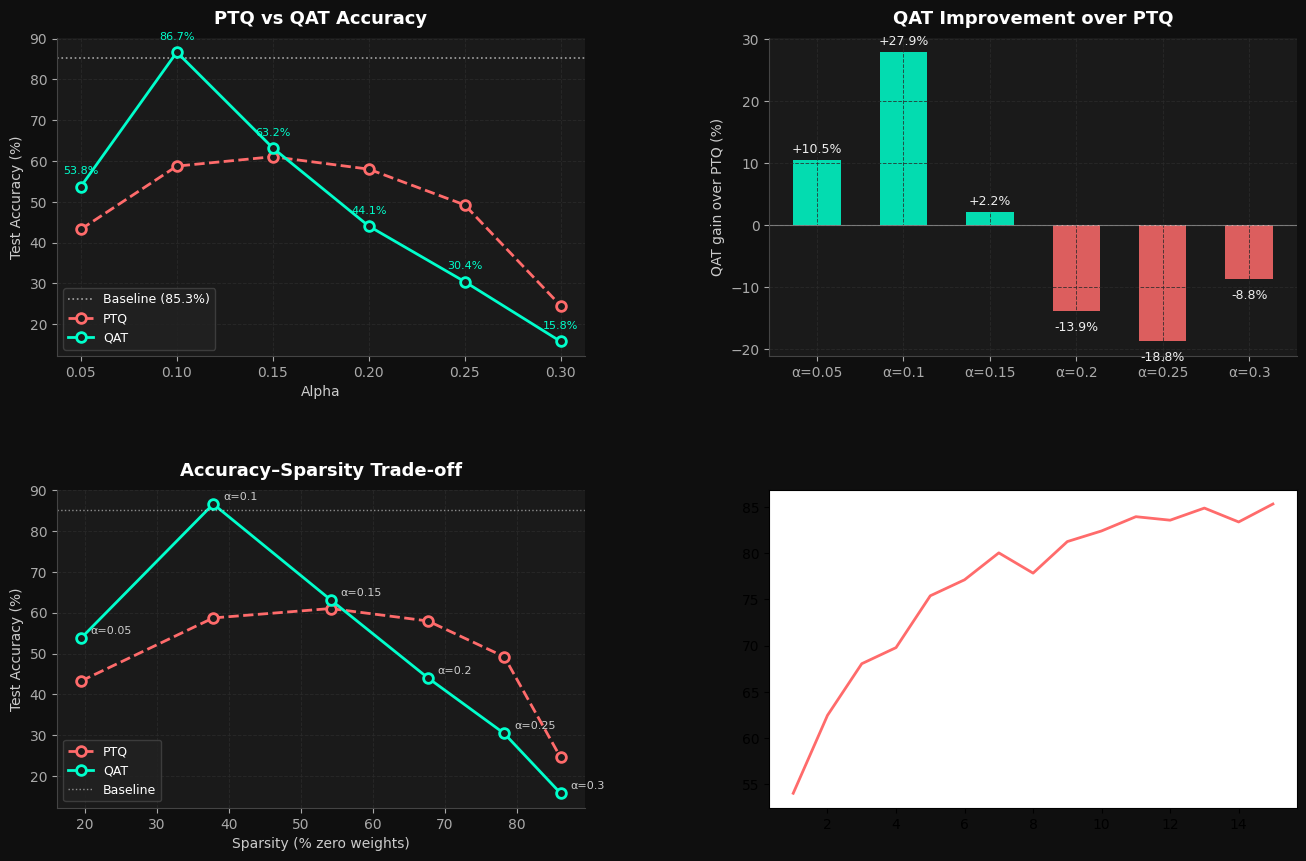

In [ ]:
alphas    = [r['alpha']        for r in results]
ptq_accs  = [r['ptq_acc']*100 for r in results]
qat_accs  = [r['qat_acc']*100 for r in results]
sparsity  = [r['pct_zero']     for r in results]

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0f0f0f')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

ACCENT, ACCENT2, ACCENT3 = '#00ffcc', '#ff6b6b', '#ffd166'
BG, GRID = '#1a1a1a', '#2a2a2a'

def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#444')
    ax.tick_params(colors='#aaa')
    ax.yaxis.label.set_color('#ccc')
    ax.xaxis.label.set_color('#ccc')
    ax.set_title(title, color='white', fontsize=13, fontweight='bold', pad=10)
    ax.grid(color=GRID, linestyle='--', linewidth=0.7, alpha=0.8)

# ── Plot 1: PTQ vs QAT accuracy ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.axhline(baseline_accuracy*100, color='white', linestyle=':',
            linewidth=1.2, alpha=0.6, label=f'Baseline ({baseline_accuracy*100:.1f}%)')
ax1.plot(alphas, ptq_accs, 'o--', color=ACCENT2, linewidth=2, markersize=7,
         markerfacecolor=BG, markeredgewidth=2, label='PTQ')
ax1.plot(alphas, qat_accs, 'o-',  color=ACCENT,  linewidth=2, markersize=7,
         markerfacecolor=BG, markeredgewidth=2, label='QAT')
for a, p, q in zip(alphas, ptq_accs, qat_accs):
    ax1.annotate(f'{q:.1f}%', (a, q), textcoords='offset points',
                 xytext=(0, 9), ha='center', color=ACCENT, fontsize=8)
ax1.set_xlabel('Alpha')
ax1.set_ylabel('Test Accuracy (%)')
ax1.legend(facecolor='#222', edgecolor='#444', labelcolor='white', fontsize=9)
style_ax(ax1, 'PTQ vs QAT Accuracy')

# ── Plot 2: QAT accuracy gain over PTQ ────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
gains = [q - p for q, p in zip(qat_accs, ptq_accs)]
colors = [ACCENT if g >= 0 else ACCENT2 for g in gains]
bars = ax2.bar(range(len(alphas)), gains, color=colors, alpha=0.85, width=0.55)
ax2.set_xticks(range(len(alphas)))
ax2.set_xticklabels([f'α={a}' for a in alphas], color='#aaa')
ax2.axhline(0, color='white', linewidth=0.8, alpha=0.4)
for i, g in enumerate(gains):
    ax2.annotate(f'{g:+.1f}%', (i, g), textcoords='offset points',
                 xytext=(0, 5 if g >= 0 else -14), ha='center', color='#eee', fontsize=9)
ax2.set_ylabel('QAT gain over PTQ (%)')
style_ax(ax2, 'QAT Improvement over PTQ')

# ── Plot 3: Accuracy–Sparsity trade-off (PTQ vs QAT) ──────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(sparsity, ptq_accs, 'o--', color=ACCENT2, linewidth=2, markersize=7,
         markerfacecolor=BG, markeredgewidth=2, label='PTQ')
ax3.plot(sparsity, qat_accs, 'o-',  color=ACCENT,  linewidth=2, markersize=7,
         markerfacecolor=BG, markeredgewidth=2, label='QAT')
for i, a in enumerate(alphas):
    ax3.annotate(f'α={a}', (sparsity[i], qat_accs[i]),
                 textcoords='offset points', xytext=(7, 3), color='#ccc', fontsize=8)
ax3.axhline(baseline_accuracy*100, color='white', linestyle=':',
            linewidth=1, alpha=0.5, label='Baseline')
ax3.set_xlabel('Sparsity (% zero weights)')
ax3.set_ylabel('Test Accuracy (%)')
ax3.legend(facecolor='#222', edgecolor='#444', labelcolor='white', fontsize=9)
style_ax(ax3, 'Accuracy–Sparsity Trade-off')

# ── Plot 4: Training curves ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
b_epochs = range(1, BASELINE_EPOCHS + 1)
q_epochs = range(BASELINE_EPOCHS + 1, BASELINE_EPOCHS + QAT_EPOCHS + 1)
ax4.plot(b_epochs, [a*100 for a in baseline_accs], color=ACCENT2, linewidth=2, label='Baseline (float)')
ax4.plot(q_epochs, [a*100 for a in qat_accs],      color=ACCENT,  linewidth=2, label='QAT (simulated ternary)')
ax4.axvline(BASELINE_EPOCHS + 0.5, color='white', linestyle='--', linewidth=1, alpha=0.4)
ax4.annotate('QAT starts', (BASELINE_EPOCHS + 0.7, min([a*100 for a in baseline_accs])),
             color='#aaa', fontsize=8)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Val Accuracy (%)')
ax4.legend(facecolor='#222', edgecolor='#444', labelcolor='white', fontsize=9)
style_ax(ax4, 'Training Curve: Baseline → QAT')

fig.suptitle(
    'Ternary Neural Networks — PTQ vs QAT\n'
    'CIFAR-10 ResNet-18: Post-Training vs Quantization-Aware Training',
    color='white', fontsize=14, fontweight='bold', y=1.01
)
plt.savefig('phase1_qat_results.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Saved: phase1_qat_results.png')

## 12. Final Summary

In [ ]:
best_qat = max(results, key=lambda r: r['qat_acc'])
best_ptq = max(results, key=lambda r: r['ptq_acc'])

print('=' * 65)
print('  PHASE 1 FINAL SUMMARY — PTQ vs QAT')
print('  CIFAR-10 / ResNet-18')
print('=' * 65)
print(f'  Baseline (float)       : {baseline_accuracy*100:.2f}%')
print()
print(f'  Best PTQ accuracy      : {best_ptq["ptq_acc"]*100:.2f}%  (α={best_ptq["alpha"]})')
print(f'    Accuracy drop        : {best_ptq["ptq_delta"]*100:+.2f}%')
print(f'    Sparsity             : {best_ptq["pct_zero"]:.1f}% zero weights')
print()
print(f'  Best QAT accuracy      : {best_qat["qat_acc"]*100:.2f}%  (α={best_qat["alpha"]})')
print(f'    Accuracy drop        : {best_qat["qat_delta"]*100:+.2f}%')
print(f'    Sparsity             : {best_qat["pct_zero"]:.1f}% zero weights')
print()
print(f'  QAT improvement over PTQ: +{(best_qat["qat_acc"] - best_ptq["ptq_acc"])*100:.2f}%')
print()
print('  Conclusion:')
print('  QAT recovers significant accuracy by letting the network')
print('  adapt to ternary constraints during training — rather than')
print('  having them imposed cold after training is complete.')
print()
print('  ✅ Phase 1 COMPLETE. Ready for Phase 2: hardware mapping.')
print('=' * 65)